<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/MODELOS_COM_OU_SEM_PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


In [15]:
#load the data
from google.colab import files
uploaded=files.upload()

Saving 01-04T184148_000_mode1.csv to 01-04T184148_000_mode1 (1).csv


In [17]:
df = pd.read_csv("01-04T184148_000_mode1.csv")

print("Dimensões da base de dados:", df.shape)
print("\nVisualização das primeiras linhas:\n", df.head())


Dimensões da base de dados: (2048, 9)

Visualização das primeiras linhas:
    timestamp  pCut::Motor_Torque  pCut::CTRL_Position_controller::Lag_error  \
0      0.008            0.199603                                   0.027420   
1      0.012            0.281624                                   0.002502   
2      0.016            0.349315                                  -0.018085   
3      0.020            0.444450                                  -0.054680   
4      0.024            0.480923                                  -0.042770   

   pCut::CTRL_Position_controller::Actual_position  \
0                                        628392628   
1                                        628392625   
2                                        628392621   
3                                        628392617   
4                                        628392613   

   pCut::CTRL_Position_controller::Actual_speed  \
0                                   -920.104980   
1                      

In [18]:
# Separação de variáveis independentes e dependente
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Divisão em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [21]:
#TESTE DE DIFERENTES VALORES DE K (sem PCA)

resultados_sem_pca = []

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    resultados_sem_pca.append([k, r2, rmse, mae])

df_sem_pca = pd.DataFrame(resultados_sem_pca, columns=["K", "R²", "RMSE", "MAE"])

In [23]:
#TESTE DE DIFERENTES VALORES DE K (com PCA)

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
print("\nVariância explicada pelos componentes:", pca.explained_variance_ratio_)
print("Variância total explicada:", np.sum(pca.explained_variance_ratio_))

resultados_com_pca = []

for k in range(1, 21):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_pca, y_train)
    y_pred = knn.predict(X_test_pca)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    resultados_com_pca.append([k, r2, rmse, mae])

df_com_pca = pd.DataFrame(resultados_com_pca, columns=["K", "R²", "RMSE", "MAE"])


Variância explicada pelos componentes: [0.44488345 0.23742609]
Variância total explicada: 0.682309543509823


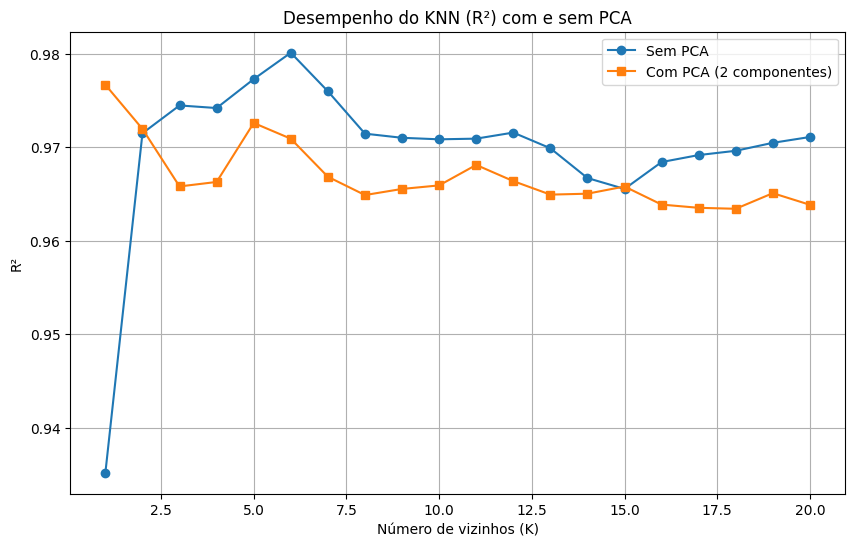

In [24]:
# 5. COMPARAÇÃO GRÁFICA
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.plot(df_sem_pca["K"], df_sem_pca["R²"], label="Sem PCA", marker='o')
plt.plot(df_com_pca["K"], df_com_pca["R²"], label="Com PCA (2 componentes)", marker='s')
plt.title("Desempenho do KNN (R²) com e sem PCA")
plt.xlabel("Número de vizinhos (K)")
plt.ylabel("R²")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
#RESULTADOS FINAIS

melhor_sem_pca = df_sem_pca.loc[df_sem_pca["R²"].idxmax()]
melhor_com_pca = df_com_pca.loc[df_com_pca["R²"].idxmax()]

print("\nMelhor configuração sem PCA:")
print(melhor_sem_pca)

print("\nMelhor configuração com PCA:")
print(melhor_com_pca)


Melhor configuração sem PCA:
K        6.000000
R²       0.980091
RMSE    10.061913
MAE      1.813365
Name: 5, dtype: float64

Melhor configuração com PCA:
K        1.000000
R²       0.976664
RMSE    10.893437
MAE      1.181452
Name: 0, dtype: float64
